# Semantic segmentation of aerial images with deep networks

This notebook presents a straightforward PyTorch implementation of a Fully Convolutional Network for semantic segmentation of aerial images. More specifically, we aim to automatically perform scene interpretation of images taken from a plane or a satellite by classifying every pixel into several land cover classes.

As a demonstration, we are going to use the [SegNet architecture](http://mi.eng.cam.ac.uk/projects/segnet/) to segment aerial images over the cities of Vaihingen and Potsdam. The images are from the [ISPRS 2D Semantic Labeling dataset](http://www2.isprs.org/commissions/comm3/wg4/results.html). We will train a network to segment roads, buildings, vegetation and cars.

This work is a PyTorch implementation of the baseline presented in ["Beyond RGB: Very High Resolution Urban Remote Sensing With Multimodal Deep Networks "](https://hal.archives-ouvertes.fr/hal-01636145), *Nicolas Audebert*, *Bertrand Le Saux* and *Sébastien Lefèvre*, ISPRS Journal, 2018.

## Requirements

This notebook requires a few useful libraries, e.g. `torch`, `scikit-image`, `numpy` and `matplotlib`. You can install everything using `pip install -r requirements.txt`.

This is expected to run on GPU, and therefore you should use `torch` in combination with CUDA/cuDNN. This can probably be made to run on CPU but be warned that:
  * you have to remove all calls to `torch.Tensor.to(device)` throughout this notebook,
  * this will be very slow.
  
A "small" GPU should be enough, e.g. this runs fine on a 4.7GB Tesla K20m. It uses quite a lot of RAM as the dataset is stored in-memory (about 5GB for Vaihingen). You can spare some memory by disabling the caching below. 4GB should be more than enough without caching.

In [1]:
import sys
print(sys.executable)

C:\Users\denisa.barb\AppData\Local\Programs\Python\Python39\python.exe


In [2]:
# imports and stuff
import numpy as np
from skimage import io
from glob import glob
from tqdm import tqdm_notebook as tqdm
from sklearn.metrics import confusion_matrix
import random
import itertools
# Matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
# Torch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
import torch.optim.lr_scheduler
import torch.nn.init
from torch.autograd import Variable

## Parameters

There are several parameters than can be tuned to use this notebook with different datasets. The default parameters are suitable for the ISPRS dataset, but you can change them to work with your data.

### Examples

  * Binary classification: `N_CLASSES = 2`
  * Multi-spectral data (e.g. IRRGB): `IN_CHANNELS = 4`
  * New folder naming convention : `DATA_FOLDER = MAIN_FOLDER + 'sentinel2/sentinel2_img_{}.tif'`

In [3]:
# Parameters
WINDOW_SIZE = (256, 256) # Patch size
STRIDE = 32 # Stride for testing
IN_CHANNELS = 3 # Number of input channels (e.g. RGB)
FOLDER = "./ISPRS_dataset/" # Replace with your "/path/to/the/ISPRS/dataset/folder/"
BATCH_SIZE = 4 # Number of samples in a mini-batch

LABELS = ["roads", "buildings", "low veg.", "trees", "cars", "clutter"] # Label names
N_CLASSES = len(LABELS) # Number of classes
WEIGHTS = torch.ones(N_CLASSES) # Weights for class balancing
CACHE = False # Store the dataset in-memory

DATASET = 'Vaihingen'

if DATASET == 'Potsdam':
    MAIN_FOLDER = FOLDER + 'Potsdam/'
    # Uncomment the next line for IRRG data
    # DATA_FOLDER = MAIN_FOLDER + '3_Ortho_IRRG/top_potsdam_{}_IRRG.tif'
    # For RGB data
    DATA_FOLDER = MAIN_FOLDER + '2_Ortho_RGB/top_potsdam_{}_RGB.tif'
    LABEL_FOLDER = MAIN_FOLDER + '5_Labels_for_participants/top_potsdam_{}_label.tif'
    ERODED_FOLDER = MAIN_FOLDER + '5_Labels_for_participants_no_Boundary/top_potsdam_{}_label_noBoundary.tif'    
elif DATASET == 'Vaihingen':
    MAIN_FOLDER = r"C:/Users/denisa.barb/Desktop/Disertatie/Vaihingen/"
    DATA_FOLDER = MAIN_FOLDER + "top/top_mosaic_09cm_area{}.tif"
    LABEL_FOLDER = MAIN_FOLDER + "gt/top_mosaic_09cm_area{}.tif"
    ERODED_FOLDER = LABEL_FOLDER


In [4]:
import os

print(DATA_FOLDER.format(1))
print(os.path.exists(DATA_FOLDER.format(1)))

print(LABEL_FOLDER.format(1))
print(os.path.exists(LABEL_FOLDER.format(1)))

C:/Users/denisa.barb/Desktop/Disertatie/Vaihingen/top/top_mosaic_09cm_area1.tif
True
C:/Users/denisa.barb/Desktop/Disertatie/Vaihingen/gt/top_mosaic_09cm_area1.tif
True


## Visualizing the dataset

First, let's check that we are able to access the dataset and see what's going on. We use ```scikit-image``` for image manipulation.

As the ISPRS dataset is stored with a ground truth in the RGB format, we need to define the color palette that can map the label id to its RGB color. We define two helper functions to convert from numeric to colors and vice-versa.

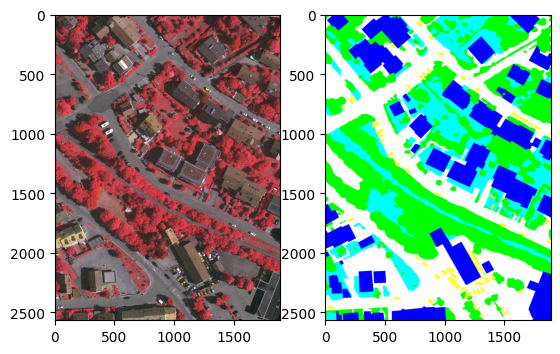

Ground truth in numerical format has shape (2566,1893) : 
 [[3 3 3 ... 3 3 3]
 [3 3 3 ... 3 3 3]
 [3 3 3 ... 3 3 3]
 ...
 [2 2 2 ... 1 1 1]
 [2 2 2 ... 1 1 1]
 [2 2 2 ... 1 1 1]]
Unique labels: [0 1 2 3 4]


In [5]:
# ISPRS color palette
# Let's define the standard ISPRS color palette
palette = {0 : (255, 255, 255), # Impervious surfaces (white)
           1 : (0, 0, 255),     # Buildings (blue)
           2 : (0, 255, 255),   # Low vegetation (cyan)
           3 : (0, 255, 0),     # Trees (green)
           4 : (255, 255, 0),   # Cars (yellow)
           5 : (255, 0, 0),     # Clutter (red)
           6 : (0, 0, 0)}       # Undefined (black)

invert_palette = {v: k for k, v in palette.items()}

def convert_to_color(arr_2d, palette=palette):
    """ Numeric labels to RGB-color encoding """
    arr_3d = np.zeros((arr_2d.shape[0], arr_2d.shape[1], 3), dtype=np.uint8)

    for c, i in palette.items():
        m = arr_2d == c
        arr_3d[m] = i

    return arr_3d

def convert_from_color(arr_3d, palette=invert_palette):
    """ RGB-color encoding to grayscale labels """
    arr_2d = np.zeros((arr_3d.shape[0], arr_3d.shape[1]), dtype=np.uint8)

    for c, i in palette.items():
        m = np.all(arr_3d == np.array(c).reshape(1, 1, 3), axis=2)
        arr_2d[m] = i

    return arr_2d

# We load one tile from the dataset and we display it
img = io.imread(DATA_FOLDER.format(11))

fig = plt.figure()
fig.add_subplot(121)
plt.imshow(img)

# We load the ground truth
gt = io.imread(LABEL_FOLDER.format(11))

fig.add_subplot(122)
plt.imshow(gt)
plt.show()

# We also check that we can convert the ground truth into an array format
array_gt = convert_from_color(gt)
print("Ground truth in numerical format has shape ({},{}) : \n".format(*array_gt.shape[:2]), array_gt)
print("Unique labels:", np.unique(array_gt))

We need to define a bunch of utils functions.

In [6]:
# Utils

def get_random_pos(img, window_shape):
    """ Extract of 2D random patch of shape window_shape in the image """
    w, h = window_shape
    W, H = img.shape[-2:]
    x1 = random.randint(0, W - w - 1)
    x2 = x1 + w
    y1 = random.randint(0, H - h - 1)
    y2 = y1 + h
    return x1, x2, y1, y2

def CrossEntropy2d(input, target, weight=None, size_average=True):
    """ 2D version of the cross entropy loss """
    dim = input.dim()
    if dim == 2:
        return F.cross_entropy(input, target, weight, size_average)
    elif dim == 4:
        output = input.view(input.size(0),input.size(1), -1)
        output = torch.transpose(output,1,2).contiguous()
        output = output.view(-1,output.size(2))
        target = target.view(-1)
        return F.cross_entropy(output, target,weight, size_average)
    else:
        raise ValueError('Expected 2 or 4 dimensions (got {})'.format(dim))

def accuracy(input, target):
    return 100 * float(np.count_nonzero(input == target)) / target.size

def sliding_window(top, step=10, window_size=(20,20)):
    """ Slide a window_shape window across the image with a stride of step """
    for x in range(0, top.shape[0], step):
        if x + window_size[0] > top.shape[0]:
            x = top.shape[0] - window_size[0]
        for y in range(0, top.shape[1], step):
            if y + window_size[1] > top.shape[1]:
                y = top.shape[1] - window_size[1]
            yield x, y, window_size[0], window_size[1]
            
def count_sliding_window(top, step=10, window_size=(20,20)):
    """ Count the number of windows in an image """
    c = 0
    for x in range(0, top.shape[0], step):
        if x + window_size[0] > top.shape[0]:
            x = top.shape[0] - window_size[0]
        for y in range(0, top.shape[1], step):
            if y + window_size[1] > top.shape[1]:
                y = top.shape[1] - window_size[1]
            c += 1
    return c

def grouper(n, iterable):
    """ Browse an iterator by chunk of n elements """
    it = iter(iterable)
    while True:
        chunk = tuple(itertools.islice(it, n))
        if not chunk:
            return
        yield chunk

def metrics(predictions, gts, label_values=LABELS):
    cm = confusion_matrix(
            gts,
            predictions,
            range(len(label_values)))
    
    print("Confusion matrix :")
    print(cm)
    
    print("---")
    
    # Compute global accuracy
    total = sum(sum(cm))
    accuracy = sum([cm[x][x] for x in range(len(cm))])
    accuracy *= 100 / float(total)
    print("{} pixels processed".format(total))
    print("Total accuracy : {}%".format(accuracy))
    
    print("---")
    
    # Compute F1 score
    F1Score = np.zeros(len(label_values))
    for i in range(len(label_values)):
        try:
            F1Score[i] = 2. * cm[i,i] / (np.sum(cm[i,:]) + np.sum(cm[:,i]))
        except:
            # Ignore exception if there is no element in class i for test set
            pass
    print("F1Score :")
    for l_id, score in enumerate(F1Score):
        print("{}: {}".format(label_values[l_id], score))

    print("---")
        
    # Compute kappa coefficient
    total = np.sum(cm)
    pa = np.trace(cm) / float(total)
    pe = np.sum(np.sum(cm, axis=0) * np.sum(cm, axis=1)) / float(total*total)
    kappa = (pa - pe) / (1 - pe);
    print("Kappa: " + str(kappa))
    return accuracy

## Loading the dataset

We define a PyTorch dataset (```torch.utils.data.Dataset```) that loads all the tiles in memory and performs random sampling. Tiles are stored in memory on the fly.

The dataset also performs random data augmentation (horizontal and vertical flips) and normalizes the data in [0, 1].

In [7]:
# Dataset class

class ISPRS_dataset(torch.utils.data.Dataset):
    def __init__(self, ids, data_files=DATA_FOLDER, label_files=LABEL_FOLDER,
                            cache=False, augmentation=True):
        super(ISPRS_dataset, self).__init__()
        
        self.augmentation = augmentation
        self.cache = cache
        
        # List of files
        self.data_files = [DATA_FOLDER.format(id) for id in ids]
        self.label_files = [LABEL_FOLDER.format(id) for id in ids]

        # Sanity check : raise an error if some files do not exist
        for f in self.data_files + self.label_files:
            if not os.path.isfile(f):
                raise KeyError('{} is not a file !'.format(f))
        
        # Initialize cache dicts
        self.data_cache_ = {}
        self.label_cache_ = {}
            
    
    def __len__(self):
        # Default epoch size is 10 000 samples
        return 10000
    
    @classmethod
    def data_augmentation(cls, *arrays, flip=True, mirror=True):
        will_flip, will_mirror = False, False
        if flip and random.random() < 0.5:
            will_flip = True
        if mirror and random.random() < 0.5:
            will_mirror = True
        
        results = []
        for array in arrays:
            if will_flip:
                if len(array.shape) == 2:
                    array = array[::-1, :]
                else:
                    array = array[:, ::-1, :]
            if will_mirror:
                if len(array.shape) == 2:
                    array = array[:, ::-1]
                else:
                    array = array[:, :, ::-1]
            results.append(np.copy(array))
            
        return tuple(results)
    
    def __getitem__(self, i):
        # Pick a random image
        random_idx = random.randint(0, len(self.data_files) - 1)
        
        # If the tile hasn't been loaded yet, put in cache
        if random_idx in self.data_cache_.keys():
            data = self.data_cache_[random_idx]
        else:
            # Data is normalized in [0, 1]
            data = 1/255 * np.asarray(io.imread(self.data_files[random_idx]).transpose((2,0,1)), dtype='float32')
            if self.cache:
                self.data_cache_[random_idx] = data
            
        if random_idx in self.label_cache_.keys():
            label = self.label_cache_[random_idx]
        else: 
            # Labels are converted from RGB to their numeric values
            label = np.asarray(convert_from_color(io.imread(self.label_files[random_idx])), dtype='int64')
            if self.cache:
                self.label_cache_[random_idx] = label

        # Get a random patch
        x1, x2, y1, y2 = get_random_pos(data, WINDOW_SIZE)
        data_p = data[:, x1:x2,y1:y2]
        label_p = label[x1:x2,y1:y2]
        
        # Data augmentation
        data_p, label_p = self.data_augmentation(data_p, label_p)

        # Return the torch.Tensor values
        return (torch.from_numpy(data_p),
                torch.from_numpy(label_p))

In [8]:
test_dataset = ISPRS_dataset([1], cache=False)

img, label = test_dataset[0]

print(img.shape)
print(label.shape)
print(torch.unique(label))

torch.Size([3, 256, 256])
torch.Size([256, 256])
tensor([0, 1, 2, 4])


## Network definition

We can now define the Fully Convolutional network based on the SegNet architecture. We could use any other network as drop-in replacement, provided that the output has dimensions `(N_CLASSES, W, H)` where `W` and `H` are the sliding window dimensions (i.e. the network should preserve the spatial dimensions).

In [12]:
class SegNet(nn.Module):
    # SegNet network
    @staticmethod
    def weight_init(m):
        if isinstance(m, nn.Linear):
            torch.nn.init.kaiming_normal(m.weight.data)
    
    def __init__(self, in_channels=IN_CHANNELS, out_channels=N_CLASSES):
        super(SegNet, self).__init__()
        self.pool = nn.MaxPool2d(2, return_indices=True)
        self.unpool = nn.MaxUnpool2d(2)
        
        self.conv1_1 = nn.Conv2d(in_channels, 64, 3, padding=1)
        self.conv1_1_bn = nn.BatchNorm2d(64)
        self.conv1_2 = nn.Conv2d(64, 64, 3, padding=1)
        self.conv1_2_bn = nn.BatchNorm2d(64)
        
        self.conv2_1 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv2_1_bn = nn.BatchNorm2d(128)
        self.conv2_2 = nn.Conv2d(128, 128, 3, padding=1)
        self.conv2_2_bn = nn.BatchNorm2d(128)
        
        self.conv3_1 = nn.Conv2d(128, 256, 3, padding=1)
        self.conv3_1_bn = nn.BatchNorm2d(256)
        self.conv3_2 = nn.Conv2d(256, 256, 3, padding=1)
        self.conv3_2_bn = nn.BatchNorm2d(256)
        self.conv3_3 = nn.Conv2d(256, 256, 3, padding=1)
        self.conv3_3_bn = nn.BatchNorm2d(256)
        
        self.conv4_1 = nn.Conv2d(256, 512, 3, padding=1)
        self.conv4_1_bn = nn.BatchNorm2d(512)
        self.conv4_2 = nn.Conv2d(512, 512, 3, padding=1)
        self.conv4_2_bn = nn.BatchNorm2d(512)
        self.conv4_3 = nn.Conv2d(512, 512, 3, padding=1)
        self.conv4_3_bn = nn.BatchNorm2d(512)
        
        self.conv5_1 = nn.Conv2d(512, 512, 3, padding=1)
        self.conv5_1_bn = nn.BatchNorm2d(512)
        self.conv5_2 = nn.Conv2d(512, 512, 3, padding=1)
        self.conv5_2_bn = nn.BatchNorm2d(512)
        self.conv5_3 = nn.Conv2d(512, 512, 3, padding=1)
        self.conv5_3_bn = nn.BatchNorm2d(512)
        
        self.conv5_3_D = nn.Conv2d(512, 512, 3, padding=1)
        self.conv5_3_D_bn = nn.BatchNorm2d(512)
        self.conv5_2_D = nn.Conv2d(512, 512, 3, padding=1)
        self.conv5_2_D_bn = nn.BatchNorm2d(512)
        self.conv5_1_D = nn.Conv2d(512, 512, 3, padding=1)
        self.conv5_1_D_bn = nn.BatchNorm2d(512)
        
        self.conv4_3_D = nn.Conv2d(512, 512, 3, padding=1)
        self.conv4_3_D_bn = nn.BatchNorm2d(512)
        self.conv4_2_D = nn.Conv2d(512, 512, 3, padding=1)
        self.conv4_2_D_bn = nn.BatchNorm2d(512)
        self.conv4_1_D = nn.Conv2d(512, 256, 3, padding=1)
        self.conv4_1_D_bn = nn.BatchNorm2d(256)
        
        self.conv3_3_D = nn.Conv2d(256, 256, 3, padding=1)
        self.conv3_3_D_bn = nn.BatchNorm2d(256)
        self.conv3_2_D = nn.Conv2d(256, 256, 3, padding=1)
        self.conv3_2_D_bn = nn.BatchNorm2d(256)
        self.conv3_1_D = nn.Conv2d(256, 128, 3, padding=1)
        self.conv3_1_D_bn = nn.BatchNorm2d(128)
        
        self.conv2_2_D = nn.Conv2d(128, 128, 3, padding=1)
        self.conv2_2_D_bn = nn.BatchNorm2d(128)
        self.conv2_1_D = nn.Conv2d(128, 64, 3, padding=1)
        self.conv2_1_D_bn = nn.BatchNorm2d(64)
        
        self.conv1_2_D = nn.Conv2d(64, 64, 3, padding=1)
        self.conv1_2_D_bn = nn.BatchNorm2d(64)
        self.conv1_1_D = nn.Conv2d(64, out_channels, 3, padding=1)
        
        self.apply(self.weight_init)
        
    def forward(self, x):
        # Encoder block 1
        x = self.conv1_1_bn(F.relu(self.conv1_1(x)))
        x = self.conv1_2_bn(F.relu(self.conv1_2(x)))
        x, mask1 = self.pool(x)
        
        # Encoder block 2
        x = self.conv2_1_bn(F.relu(self.conv2_1(x)))
        x = self.conv2_2_bn(F.relu(self.conv2_2(x)))
        x, mask2 = self.pool(x)
        
        # Encoder block 3
        x = self.conv3_1_bn(F.relu(self.conv3_1(x)))
        x = self.conv3_2_bn(F.relu(self.conv3_2(x)))
        x = self.conv3_3_bn(F.relu(self.conv3_3(x)))
        x, mask3 = self.pool(x)
        
        # Encoder block 4
        x = self.conv4_1_bn(F.relu(self.conv4_1(x)))
        x = self.conv4_2_bn(F.relu(self.conv4_2(x)))
        x = self.conv4_3_bn(F.relu(self.conv4_3(x)))
        x, mask4 = self.pool(x)
        
        # Encoder block 5
        x = self.conv5_1_bn(F.relu(self.conv5_1(x)))
        x = self.conv5_2_bn(F.relu(self.conv5_2(x)))
        x = self.conv5_3_bn(F.relu(self.conv5_3(x)))
        x, mask5 = self.pool(x)
        
        # Decoder block 5
        x = self.unpool(x, mask5)
        x = self.conv5_3_D_bn(F.relu(self.conv5_3_D(x)))
        x = self.conv5_2_D_bn(F.relu(self.conv5_2_D(x)))
        x = self.conv5_1_D_bn(F.relu(self.conv5_1_D(x)))
        
        # Decoder block 4
        x = self.unpool(x, mask4)
        x = self.conv4_3_D_bn(F.relu(self.conv4_3_D(x)))
        x = self.conv4_2_D_bn(F.relu(self.conv4_2_D(x)))
        x = self.conv4_1_D_bn(F.relu(self.conv4_1_D(x)))
        
        # Decoder block 3
        x = self.unpool(x, mask3)
        x = self.conv3_3_D_bn(F.relu(self.conv3_3_D(x)))
        x = self.conv3_2_D_bn(F.relu(self.conv3_2_D(x)))
        x = self.conv3_1_D_bn(F.relu(self.conv3_1_D(x)))
        
        # Decoder block 2
        x = self.unpool(x, mask2)
        x = self.conv2_2_D_bn(F.relu(self.conv2_2_D(x)))
        x = self.conv2_1_D_bn(F.relu(self.conv2_1_D(x)))
        
        # Decoder block 1
        x = self.unpool(x, mask1)
        x = self.conv1_2_D_bn(F.relu(self.conv1_2_D(x)))
        x = F.log_softmax(self.conv1_1_D(x), dim=1)
        return x

We can now instantiate the network using the specified parameters. By default, the weights will be initialized using the [He policy](https://www.cv-foundation.org/openaccess/content_iccv_2015/papers/He_Delving_Deep_into_ICCV_2015_paper.pdf).

In [10]:
# instantiate the network
net = SegNet()

In [13]:
net = SegNet()
net.eval()

x = img.unsqueeze(0)   # adaugă batch dimension: [1, 3, 256, 256]

with torch.no_grad():
    y = net(x)

print(y.shape)

torch.Size([1, 6, 256, 256])


We download and load the pre-trained weights from VGG-16 on ImageNet. This step is optional but it makes the network converge faster. We skip the weights from VGG-16 that have no counterpart in SegNet.

In [14]:
import os
try:
    from urllib.request import URLopener
except ImportError:
    from urllib import URLopener

# Download VGG-16 weights from PyTorch
vgg_url = 'https://download.pytorch.org/models/vgg16_bn-6c64b313.pth'
if not os.path.isfile('./vgg16_bn-6c64b313.pth'):
    weights = URLopener().retrieve(vgg_url, './vgg16_bn-6c64b313.pth')

vgg16_weights = torch.load('./vgg16_bn-6c64b313.pth', map_location=torch.device('cpu'))
mapped_weights = {}
for k_vgg, k_segnet in zip(vgg16_weights.keys(), net.state_dict().keys()):
    if "features" in k_vgg:
        mapped_weights[k_segnet] = vgg16_weights[k_vgg]
        print("Mapping {} to {}".format(k_vgg, k_segnet))
        
try:
    net.load_state_dict(mapped_weights)
    print("Loaded VGG-16 weights in SegNet !")
except:
    # Ignore missing keys
    pass

Mapping features.0.weight to conv1_1.weight
Mapping features.0.bias to conv1_1.bias
Mapping features.1.weight to conv1_1_bn.weight
Mapping features.1.bias to conv1_1_bn.bias
Mapping features.1.running_mean to conv1_1_bn.running_mean
Mapping features.1.running_var to conv1_1_bn.running_var
Mapping features.3.weight to conv1_1_bn.num_batches_tracked
Mapping features.3.bias to conv1_2.weight
Mapping features.4.weight to conv1_2.bias
Mapping features.4.bias to conv1_2_bn.weight
Mapping features.4.running_mean to conv1_2_bn.bias
Mapping features.4.running_var to conv1_2_bn.running_mean
Mapping features.7.weight to conv1_2_bn.running_var
Mapping features.7.bias to conv1_2_bn.num_batches_tracked
Mapping features.8.weight to conv2_1.weight
Mapping features.8.bias to conv2_1.bias
Mapping features.8.running_mean to conv2_1_bn.weight
Mapping features.8.running_var to conv2_1_bn.bias
Mapping features.10.weight to conv2_1_bn.running_mean
Mapping features.10.bias to conv2_1_bn.running_var
Mapping fe

Then, we load the network on GPU.

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

net = net.to(device)

cpu


### Loading the data

We now create a train/test split. If you want to use another dataset, you have to adjust the method to collect all filenames. In our case, we specify a fixed train/test split for the demo.

In [16]:
# Load the datasets
if DATASET == 'Potsdam':
    all_files = sorted(glob(LABEL_FOLDER.replace('{}', '*')))
    all_ids = ["".join(f.split('')[5:7]) for f in all_files]
elif DATASET == 'Vaihingen':
    all_files = sorted(glob(LABEL_FOLDER.replace('{}', '*')))
    all_ids = [f.split('area')[-1].split('.')[0] for f in all_files]

# Fixed Vaihingen train/validation split used for the dissertation experiments
train_ids = ['1', '3', '23', '26', '7', '11', '13', '28', '17', '32', '34', '37']
test_ids = ['5', '21', '15', '30']

print("Tiles for training : ", train_ids)
print("Tiles for testing : ", test_ids)

train_set = ISPRS_dataset(train_ids, cache=CACHE)
train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)


Tiles for training :  ['1', '3']
Tiles for testing :  ['5']


In [17]:
imgs, labels = next(iter(train_loader))

print(imgs.shape)
print(labels.shape)
print(torch.unique(labels))

torch.Size([10, 3, 256, 256])
torch.Size([10, 256, 256])
tensor([0, 1, 2, 3, 4])


### Designing the optimizer

We use the standard Stochastic Gradient Descent algorithm to optimize the network's weights.

The encoder is trained at half the learning rate of the decoder, as we rely on the pre-trained VGG-16 weights. We use the ``torch.optim.lr_scheduler`` to reduce the learning rate by 10 after 25, 35 and 45 epochs.

In [18]:
base_lr = 0.01
params_dict = dict(net.named_parameters())
params = []
for key, value in params_dict.items():
    if '_D' in key:
        # Decoder weights are trained at the nominal learning rate
        params += [{'params':[value],'lr': base_lr}]
    else:
        # Encoder weights are trained at lr / 2 (we have VGG-16 weights as initialization)
        params += [{'params':[value],'lr': base_lr / 2}]

optimizer = optim.SGD(params, lr=base_lr, momentum=0.9, weight_decay=0.0005)
# We define the scheduler
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, [25, 35, 45], gamma=0.1)

In [ ]:
# Results utilities for dissertation experiments
import os
import csv
from datetime import datetime

RESULTS_DIR = "results_segnet"
CHECKPOINT_DIR = os.path.join(RESULTS_DIR, "checkpoints")
PREDICTIONS_DIR = os.path.join(RESULTS_DIR, "predictions")
METRICS_CSV = os.path.join(RESULTS_DIR, "metrics.csv")
RESULTS_TXT = os.path.join(RESULTS_DIR, "results_segnet.txt")

for folder in [RESULTS_DIR, CHECKPOINT_DIR, PREDICTIONS_DIR]:
    os.makedirs(folder, exist_ok=True)

class_names = [
    "Impervious surfaces",
    "Buildings",
    "Low vegetation",
    "Trees",
    "Cars",
    "Clutter/background"
]

def compute_class_iou(pred, target, num_classes=N_CLASSES):
    ious = []
    pred = np.asarray(pred)
    target = np.asarray(target)

    for cls in range(num_classes):
        pred_cls = pred == cls
        target_cls = target == cls

        intersection = np.logical_and(pred_cls, target_cls).sum()
        union = np.logical_or(pred_cls, target_cls).sum()

        if union == 0:
            ious.append(np.nan)
        else:
            ious.append(intersection / union)

    return np.array(ious, dtype=np.float32)

def save_comparison_png(rgb, gt, pred, save_path):
    rgb = np.asarray(rgb)
    if rgb.max() <= 1.0:
        rgb = (255 * rgb).astype(np.uint8)
    else:
        rgb = rgb.astype(np.uint8)

    gt_color = convert_to_color(gt)
    pred_color = convert_to_color(pred)

    # Ensure all images have the same height/width
    h, w = gt_color.shape[:2]
    if rgb.shape[:2] != (h, w):
        import cv2
        rgb = cv2.resize(rgb, (w, h))

    comparison = np.concatenate([rgb, gt_color, pred_color], axis=1)
    io.imsave(save_path, comparison)

def init_results_files():
    with open(RESULTS_TXT, "w", encoding="utf-8") as f:
        f.write("SegNet training results\n")
        f.write("Created: {}\n".format(datetime.now()))
        f.write("Dataset: {}\n".format(DATASET))
        f.write("Training tiles: {}\n".format(train_ids))
        f.write("Validation tiles: {}\n".format(test_ids))
        f.write("Batch size: {}\n".format(BATCH_SIZE))
        f.write("Window size: {}\n".format(WINDOW_SIZE))
        f.write("Device: {}\n".format(device))
        f.write("----------------------------------------\n")

    with open(METRICS_CSV, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow([
            "epoch",
            "train_loss",
            "train_pixel_accuracy",
            "val_pixel_accuracy",
            "miou",
            "iou_impervious",
            "iou_buildings",
            "iou_low_vegetation",
            "iou_trees",
            "iou_cars",
            "iou_clutter"
        ])

def save_epoch_results(epoch, train_loss, train_acc, val_acc, class_iou):
    miou = np.nanmean(class_iou)

    with open(RESULTS_TXT, "a", encoding="utf-8") as f:
        f.write("========== Epoch {} ==========\n".format(epoch))
        f.write("Training loss: {:.6f}\n".format(train_loss))
        f.write("Training pixel accuracy: {:.6f}\n".format(train_acc))
        f.write("Validation pixel accuracy: {:.6f}\n".format(val_acc))
        f.write("mIoU: {:.6f}\n".format(miou))
        f.write("Class-wise IoU:\n")
        for name, value in zip(class_names, class_iou):
            f.write("  {:22s}: {:.6f}\n".format(name, value if not np.isnan(value) else -1))
        f.write("----------------------------------------\n\n")

    with open(METRICS_CSV, "a", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow([
            epoch,
            train_loss,
            train_acc,
            val_acc,
            miou,
            *class_iou
        ])


In [19]:
def test(net, test_ids, all=False, stride=WINDOW_SIZE[0], batch_size=BATCH_SIZE,
         window_size=WINDOW_SIZE, save_epoch=None, save_predictions=True, display=False):
    """Evaluate SegNet on the validation/test tiles and save prediction images."""
    test_images = (1 / 255 * np.asarray(io.imread(DATA_FOLDER.format(id)), dtype='float32') for id in test_ids)
    test_labels = (np.asarray(io.imread(LABEL_FOLDER.format(id)), dtype='uint8') for id in test_ids)
    eroded_labels = (convert_from_color(io.imread(ERODED_FOLDER.format(id))) for id in test_ids)

    all_preds = []
    all_gts = []
    all_rgb = []

    net.eval()

    with torch.no_grad():
        for tile_idx, (img, gt, gt_e) in enumerate(tqdm(zip(test_images, test_labels, eroded_labels),
                                                        total=len(test_ids), leave=False)):
            pred = np.zeros(img.shape[:2] + (N_CLASSES,))

            total = max(1, count_sliding_window(img, step=stride, window_size=window_size) // batch_size)

            for coords in tqdm(grouper(batch_size, sliding_window(img, step=stride, window_size=window_size)),
                               total=total, leave=False):
                image_patches = [np.copy(img[x:x+w, y:y+h]).transpose((2,0,1)) for x,y,w,h in coords]
                image_patches = np.asarray(image_patches)
                image_patches = torch.from_numpy(image_patches).to(device)

                outs = net(image_patches)
                outs = outs.detach().cpu().numpy()

                for out, (x, y, w, h) in zip(outs, coords):
                    out = out.transpose((1,2,0))
                    pred[x:x+w, y:y+h] += out

            pred = np.argmax(pred, axis=-1)

            all_preds.append(pred)
            all_gts.append(gt_e)
            all_rgb.append(img)

            if save_predictions and save_epoch is not None and tile_idx == 0:
                save_path = os.path.join(PREDICTIONS_DIR, "epoch_{}_prediction.png".format(save_epoch))
                save_comparison_png(np.asarray(255 * img, dtype='uint8'), gt_e, pred, save_path)

            if display:
                clear_output(wait=True)
                fig = plt.figure()
                fig.add_subplot(1,3,1)
                plt.imshow(np.asarray(255 * img, dtype='uint8'))
                plt.title("RGB")
                fig.add_subplot(1,3,2)
                plt.imshow(convert_to_color(pred))
                plt.title("Prediction")
                fig.add_subplot(1,3,3)
                plt.imshow(gt)
                plt.title("Ground truth")
                plt.show()

    flat_preds = np.concatenate([p.ravel() for p in all_preds])
    flat_gts = np.concatenate([g.ravel() for g in all_gts])

    val_acc = accuracy(flat_preds, flat_gts)
    class_iou = compute_class_iou(flat_preds, flat_gts, N_CLASSES)

    print("Validation pixel accuracy: {:.6f}".format(val_acc))
    print("Validation mIoU: {:.6f}".format(np.nanmean(class_iou)))
    print("Class-wise IoU:")
    for name, value in zip(class_names, class_iou):
        print("  {}: {:.6f}".format(name, value if not np.isnan(value) else -1))

    if all:
        return val_acc, class_iou, all_preds, all_gts
    else:
        return val_acc, class_iou


In [21]:
from IPython.display import clear_output

def train(net, optimizer, epochs, scheduler=None, weights=WEIGHTS, save_epoch=10):
    init_results_files()

    weights = weights.to(device)
    iter_ = 0

    for e in range(1, epochs + 1):
        if scheduler is not None:
            scheduler.step()

        net.train()

        epoch_losses = []
        epoch_accs = []

        for batch_idx, (data, target) in enumerate(train_loader):
            data = data.to(device)
            target = target.to(device)

            optimizer.zero_grad()
            output = net(data)

            loss = CrossEntropy2d(output, target, weight=weights)
            loss.backward()
            optimizer.step()

            pred = np.argmax(output.detach().cpu().numpy()[0], axis=0)
            gt = target.detach().cpu().numpy()[0]

            batch_acc = accuracy(pred, gt)
            epoch_losses.append(loss.item())
            epoch_accs.append(batch_acc)

            if iter_ % 100 == 0:
                clear_output(wait=True)

                rgb = np.asarray(
                    255 * np.transpose(data.detach().cpu().numpy()[0], (1, 2, 0)),
                    dtype='uint8'
                )

                print(
                    'Train (epoch {}/{}) [{}/{} ({:.0f}%)]\tLoss: {:.6f}\tAccuracy: {:.4f}'.format(
                        e, epochs, batch_idx, len(train_loader),
                        100. * batch_idx / len(train_loader),
                        loss.item(),
                        batch_acc
                    )
                )

                fig = plt.figure()
                fig.add_subplot(131)
                plt.imshow(rgb)
                plt.title('RGB')

                fig.add_subplot(132)
                plt.imshow(convert_to_color(gt))
                plt.title('Ground truth')

                fig.add_subplot(133)
                plt.title('Prediction')
                plt.imshow(convert_to_color(pred))
                plt.show()

            iter_ += 1

            del data, target, loss

        train_loss = float(np.mean(epoch_losses))
        train_acc = float(np.mean(epoch_accs))

        # Validate and save results at epoch 1 and every save_epoch epochs
        if e == 1 or e % save_epoch == 0:
            val_acc, class_iou = test(
                net,
                test_ids,
                all=False,
                stride=min(WINDOW_SIZE),
                save_epoch=e,
                save_predictions=True,
                display=False
            )

            save_epoch_results(e, train_loss, train_acc, val_acc, class_iou)

            checkpoint_path = os.path.join(CHECKPOINT_DIR, "segnet_epoch_{}.pth".format(e))
            torch.save(net.state_dict(), checkpoint_path)
            print("Saved checkpoint:", checkpoint_path)

    final_path = os.path.join(CHECKPOINT_DIR, "segnet_final.pth")
    torch.save(net.state_dict(), final_path)
    print("Training finished. Final model saved to:", final_path)


### Training the network

Let's train the network for 50 epochs. The `matplotlib` graph is periodically udpated with the loss plot and a sample inference. Depending on your GPU, this might take from a few hours (Titan Pascal) to a full day (old K20).

Train (epoch 1/1) [0/1000 (0%)]	Loss: 1.926338	Accuracy: 14.9200439453125


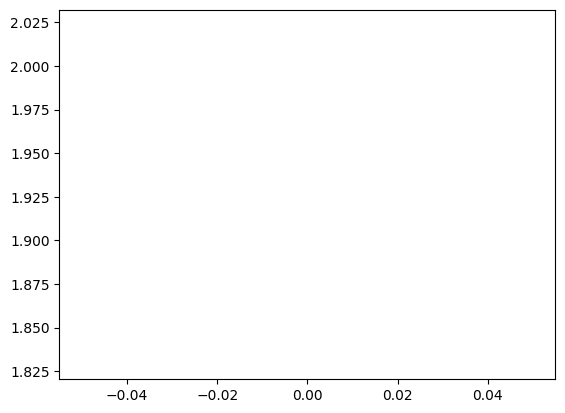

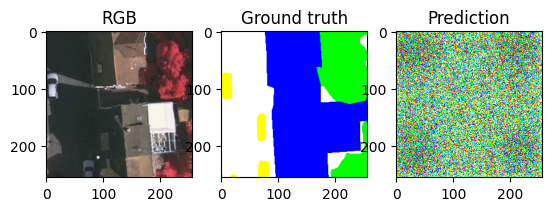

Mini-training test finished successfully.


In [22]:
train(net, optimizer, 100, scheduler, save_epoch=10)


### Testing the network

Now that the training has ended, we can load the final weights and test the network using a reasonable stride, e.g. half or a quarter of the window size. Inference time depends on the chosen stride, e.g. a step size of 32 (75% overlap) will take ~15 minutes, but no overlap will take only one minute or two.

In [15]:
net.load_state_dict(torch.load('./segnet_final'))

In [16]:
_, all_preds, all_gts = test(net, test_ids, all=True, stride=32)

Confusion matrix :
[[1176243   27917   40719   12367    3237    3681]
 [  43457 1148303    7376    1855       0     542]
 [  59760   19017  745166  135844       0       0]
 [   3575     254   41492  929409       4       0]
 [   4856    1464     253     326   49146       0]
 [      0       0       0       0       0       0]]
---
4456263 pixels processed
Total accuracy : 90.84443624624488%
---
F1Score :
roads: 0.9218006665216855
buildings: 0.9575224057823095
low veg.: 0.8303642815633892
trees: 0.9047390285393045
cars: 0.9064851704293936
clutter: 0.0
---
Kappa: 0.878264212814
Confusion matrix :
[[4444836  133148  145598   59877    8599   12307]
 [ 251606 5128036   28565   10388     735    3617]
 [ 169340   58698 2272628  393683     171    8190]
 [  40707    7712  327441 4016691     209       0]
 [  12351    2995     253     628  130669    1781]
 [      0       0    6216       0       0       0]]
---
17677675 pixels processed
Total accuracy : 90.46925005692208%
---
F1Score :
roads: 0.91427

### Saving the results

We can visualize and save the resulting tiles for qualitative assessment.

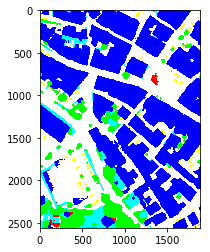

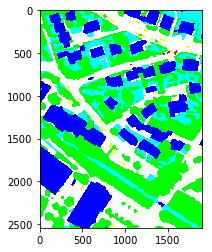

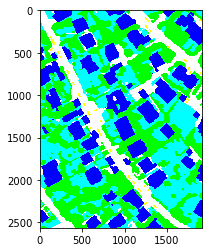

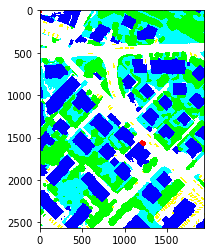

In [17]:
for p, id_ in zip(all_preds, test_ids):
    img = convert_to_color(p)
    plt.imshow(img) and plt.show()
    io.imsave('./inference_tile_{}.png'.format(id_), img)